In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import hvplot.xarray
# from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from scipy.optimize import curve_fit

import plotly.express as px

[ 1.08724104e-13 -5.76010740e-13 -2.00298037e-09  8.44593881e-09
  5.00664279e-06 -2.77843394e-05 -1.32053852e-01  5.84575839e-03]


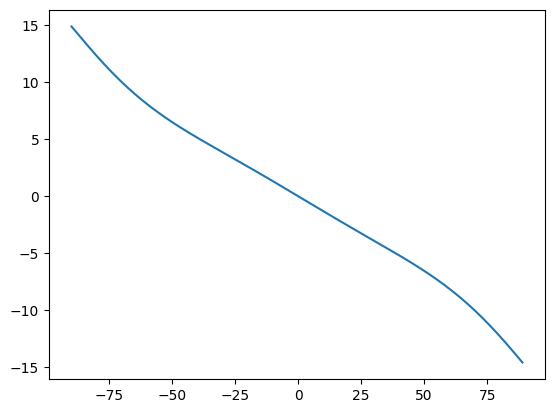

In [3]:
calib_dir = "C:\\Users\\Ralph Group\\Documents\\Github\\SagnacOperatingSys\\sagnac_control\\calibrations\\old_calibrations\\pre20260430\\"
radial_polar_coeff= np.loadtxt(calib_dir + 'sagnac_radial_polar_calib.csv', delimiter=',')
radial_polar_calib = np.poly1d(radial_polar_coeff)
theta = np.arange(-90, 90, 1)
plt.plot(theta, radial_polar_calib(theta))
print(radial_polar_coeff)

In [4]:
measured = pd.read_csv('2026-05-07/test_daedalus_radialPolar_calib_A090.0_2026-05-07_1.csv', comment = '#')
measured.theta = np.arctan2(-measured.Yfield,-measured.Zfield) * 180 / np.pi
measured.theta = -measured.theta #flip to follow daedalus convention
measured.columns

px.line(measured, x='R', y='theta', title='Measured Radial Distance vs Theta')


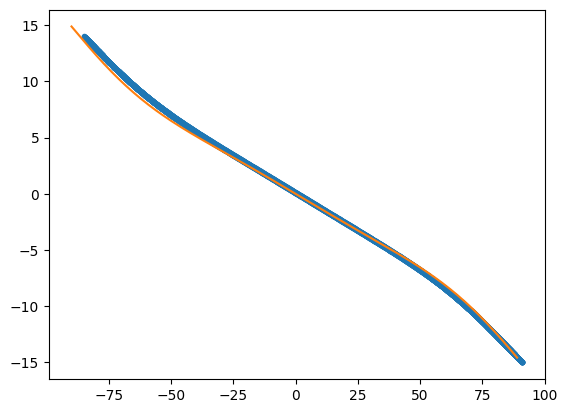

In [5]:

ds = xr.Dataset(measured)
ds = ds.where(ds.R < 14, drop=True)
plt.plot(ds['theta'], ds['R'],'.')
plt.plot(theta, radial_polar_calib(theta))

[-2.67834378e-10  4.39391631e-09 -2.50667126e-06 -9.26196092e-06
 -1.30823442e-01  1.04419555e-01]


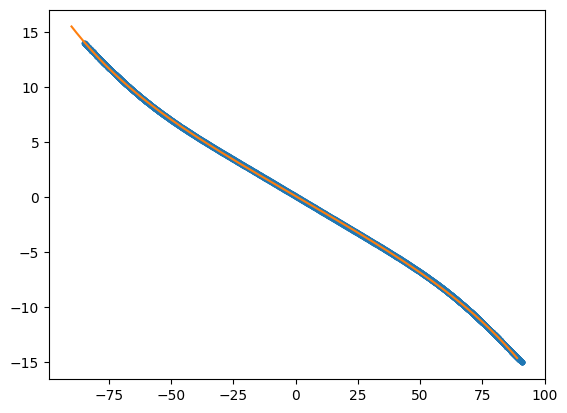

In [6]:
theta = np.arange(-90, 90, 1)
#plt.plot(theta, radial_polar_calib(theta))
plt.plot(ds['theta'], ds['R'], '.')

radial_polar_coeff_new = np.polyfit(ds['theta'], ds['R'], 5)
print(radial_polar_coeff_new)
radial_polar_calib_new = np.poly1d(radial_polar_coeff_new)
plt.plot(theta, radial_polar_calib_new(theta))

In [ ]:
## old. IDK why they had these sign flips.
# theta = np.arange(-90, 90, 1)
# #plt.plot(theta, radial_polar_calib(theta))
# plt.plot(-ds['theta'], ds['R'], '.')

# radial_polar_coeff_new = np.polyfit(-ds['theta'], ds['R'], 5)
# print(radial_polar_coeff_new)
# radial_polar_calib_new = np.poly1d(radial_polar_coeff_new)
# plt.plot(theta, radial_polar_calib_new(theta))
# #save to radial_polar (radial_polar)